In [1]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 17.5 MB/s eta 0:00:00


 Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Using device: CUDA
 Initializing GlassBox-ViT (SmoothGradExplainer)...
 Loading and resizing test image (Chelsea the cat)...
 Generating Smooth Grad Feature Visualization...

 Smooth Grad VISUALIZATION GENERATED SUCCESSFULLY
-> Model Prediction: Egyptian cat (97.55%)


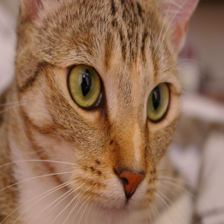

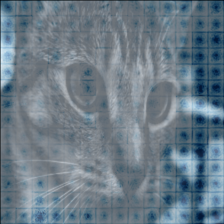

In [11]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data
from IPython.display import display

from smoothgrad_explainer import SmoothGradExplainer

# --- MODEL SETUP ---
print(" Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)


model = AutoModelForImageClassification.from_pretrained(
    model_name
)

# The user  decides where the model lives
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")
model.to(device)

# Extract class names from the model config
class_names = list(model.config.id2label.values())

# --- INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (SmoothGradExplainer)...")
# Model and processor. Device is auto-detected internally.
smoothgrad_explainer = SmoothGradExplainer(
    model=model,
    processor=processor
)

# --- LOAD TEST IMAGE ---
print(" Loading and resizing test image (Chelsea the cat)...")
image_np = data.chelsea()
# ViT models expect 224x224 images
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

# --- GENERATE EXPLANATION ---
print(" Generating Smooth Grad Feature Visualization...")

result = smoothgrad_explainer.generate(pil_image=test_image)

# --- DISPLAY RESULTS  ---
# Extract final metrics
predicted_class = class_names[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n Smooth Grad VISUALIZATION GENERATED SUCCESSFULLY")
print(f"-> Model Prediction: {predicted_class} ({confidence:.2f}%)")

# Display the image directly in the notebook cell output
display(test_image)
display(result['smoothgrad_image'])